# MPro GINE Regression Notebook

This notebook builds an end-to-end graph regression pipeline to predict ligand $pIC50$ values for SARS-CoV-2 main protease inhibitors with a GINE-style message-passing model.

## What this notebook covers

1. Environment setup and run configuration
2. Molecular graph construction from the `.smi` ligand files
3. Data-loader sanity checks
4. GINE model definition
5. Training, validation, and optional hyperparameter search
6. Test-set prediction, regression metrics, and visualization

## Main outputs

Running the full workflow produces the following artifacts inside `notebooks/mpro_gine_regression/artifacts`:

- Cached graph tensors for faster reruns
- The best training checkpoint
- A JSON file with training history
- A CSV file with test-set predictions
- Optional hyperparameter search results

## Suggested execution order

1. Run the setup and graph-construction sections once per session.
2. Optionally run the hyperparameter-search section if model tuning is needed.
3. Run the training section to save the best checkpoint.
4. Run the prediction and evaluation sections to inspect final performance.

## Environment

Open this notebook with the Python environment that already contains PyTorch, RDKit, scikit-learn, SciPy, pandas, and matplotlib.

```bash
conda activate digress
```

This section is split into two setup cells: one dedicated Imports cell and one runtime/helper cell.

This notebook expects the repository layout to remain unchanged, especially the `MPro-URV_Version2` directory and the ligand `.smi` files under `MPro-URV_Version2/Ligand/Ligand_SMI`.

A few practical notes before running the heavy cells:

- Graph generation is cached on disk, so the expensive preprocessing step only needs to run once unless the source data changes.
- The hyperparameter-search section is computationally expensive because it trains many candidate models.
- The ROC/AUC plot treats the regression output as an activity score using the threshold `pIC50 >= 6.0`.

### Imports

This cell contains all imports used throughout the notebook. It should be run before any other code cell in the notebook.

In [7]:
from __future__ import annotations

# Standard library imports
import copy
import json
import math
import random
from pathlib import Path
from typing import Any, Dict, List

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from rdkit import Chem, RDLogger
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset
from itertools import product
from time import perf_counter

### Runtime Setup and Display Helpers

This cell configures logging, plotting style, random seeds, device selection, and the small helper functions used to format notebook output.

In [8]:
# Keep the notebook output focused on useful information.
RDLogger.DisableLog('rdApp.*')
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Use a GPU when it is available, otherwise fall back to CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def print_banner(title: str, width: int = 88, char: str = '=') -> None:
    """Print a clear section divider in notebook output."""
    rule = char * width
    print(f"\n{rule}\n{title}\n{rule}")


def display_key_values(title: str, values: Dict[str, Any]) -> None:
    """Display a small key-value table with a visible title."""
    print_banner(title)
    frame = pd.DataFrame({'value': pd.Series(values, dtype='object')})
    display(frame)


def display_metric_table(title: str, metrics: Dict[str, float], digits: int = 4) -> None:
    """Display metrics in a compact, consistently formatted table."""
    print_banner(title)
    metric_frame = pd.DataFrame(
        {
            'metric': list(metrics.keys()),
            'value': list(metrics.values()),
        }
    )
    display(metric_frame.round(digits))


display_key_values(
    'Runtime context',
    {
        'Random seed': SEED,
        'Device': str(DEVICE),
        'PyTorch version': torch.__version__,
        'NumPy version': np.__version__,
        'Pandas version': pd.__version__,
    },
)


Runtime context


,value
Random seed,42
Device,cpu
PyTorch version,2.8.0+cpu
NumPy version,1.26.4
Pandas version,2.3.1


### Paths and Run Configuration

This section resolves the repository root, defines the data and artifact locations, and centralizes the default model and training hyperparameters.

If changes to the run configuration are needed, this is the main cell to edit first. Typical adjustments include:

- `BATCH_SIZE` for memory usage
- `HIDDEN_DIM`, `NUM_LAYERS`, and `DROPOUT` for model capacity
- `LEARNING_RATE`, `WEIGHT_DECAY`, `MAX_EPOCHS`, and `PATIENCE` for optimization behavior
- `FORCE_REBUILD_GRAPHS` if cached graph tensors need to be regenerated

In [9]:
def find_repo_root(start_path: Path) -> Path:
    """Walk upward until the project root containing the dataset is found."""
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'MPro-URV_Version2').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing MPro-URV_Version2.')


# Resolve the core project paths used throughout the notebook.
REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = REPO_ROOT / 'MPro-URV_Version2'
SMI_DIR = DATA_ROOT / 'Ligand' / 'Ligand_SMI'
TRAIN_CSV = DATA_ROOT / 'train.csv'
VAL_CSV = DATA_ROOT / 'val.csv'
TEST_CSV = DATA_ROOT / 'test.csv'

# Keep all notebook-generated files in one place.
ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'mpro_gine_regression' / 'artifacts'
HPARAMS_PATH = ARTIFACT_DIR / 'gine_best_hparams.json'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_CACHE = ARTIFACT_DIR / 'mpro_graph_cache.pt'
CHECKPOINT_PATH = ARTIFACT_DIR / 'gine_pic50_regressor.pt'
PREDICTIONS_PATH = ARTIFACT_DIR / 'test_predictions.csv'
HISTORY_PATH = ARTIFACT_DIR / 'training_history.json'

# Default training and model hyperparameters.
BATCH_SIZE = 32
HIDDEN_DIM = 128
NUM_LAYERS = 4
DROPOUT = 0.15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 300
PATIENCE = 40

# ---- Override if best hyperparameters file exists ----
if HPARAMS_PATH.exists():
    with open(HPARAMS_PATH, "r") as f:
        hparams = json.load(f)

    BATCH_SIZE = int(hparams.get("batch_size", BATCH_SIZE))
    HIDDEN_DIM = int(hparams.get("hidden_dim", HIDDEN_DIM))
    NUM_LAYERS = int(hparams.get("num_layers", NUM_LAYERS))
    DROPOUT = float(hparams.get("dropout", DROPOUT))
    LEARNING_RATE = float(hparams.get("learning_rate", LEARNING_RATE))
    WEIGHT_DECAY = float(hparams.get("weight_decay", WEIGHT_DECAY))
    MAX_EPOCHS = int(hparams.get("max_epochs", MAX_EPOCHS))
    PATIENCE = int(hparams.get("patience", PATIENCE))

ACTIVE_THRESHOLD = 6.0
FORCE_REBUILD_GRAPHS = False
LOSS_NAME = 'rmse'

BASE_MODEL_CONFIG = {
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
}
BASE_TRAINING_CONFIG = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'loss_name': LOSS_NAME,
}

display_key_values(
    'Resolved paths',
    {
        'Repository root': REPO_ROOT,
        'Data root': DATA_ROOT,
        'SMILES directory': SMI_DIR,
        'Artifact directory': ARTIFACT_DIR,
        'Checkpoint path': CHECKPOINT_PATH,
    },
)

print_banner('Default configuration')
display(
    pd.DataFrame(
        [
            {'group': 'model', 'name': key, 'value': value}
            for key, value in BASE_MODEL_CONFIG.items()
        ]
        + [
            {'group': 'training', 'name': key, 'value': value}
            for key, value in BASE_TRAINING_CONFIG.items()
        ]
        + [
            {'group': 'general', 'name': 'active_threshold', 'value': ACTIVE_THRESHOLD},
            {'group': 'general', 'name': 'force_rebuild_graphs', 'value': FORCE_REBUILD_GRAPHS},
        ]
    )
)


Resolved paths


,value
Repository root,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Data root,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
SMILES directory,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Artifact directory,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...



Default configuration


,group,name,value
0,model,hidden_dim,256
1,model,num_layers,6
2,model,dropout,0.05
3,training,batch_size,32
4,training,learning_rate,0.0005
5,training,weight_decay,0.00001
6,training,max_epochs,300
7,training,patience,50
8,training,loss_name,rmse
9,general,active_threshold,6.0


## Graph Definition

Each ligand is converted into a graph where atoms are nodes and bonds are represented as bidirectional edges. The `.smi` file is treated as the source of truth for each molecule string.

### Feature design

- Node features encode atom identity, hybridization, degree, hydrogen count, formal charge, aromaticity, ring membership, and a scaled atomic mass.
- Edge features encode bond type, stereochemistry, conjugation, and ring membership.

The next code cell handles four jobs in one place:

1. Define the node and edge featurization functions.
2. Read the train, validation, and test splits.
3. Build graph objects or reload them from cache.
4. Compute the feature dimensions and target normalization statistics used later by the model.

In [10]:
# Common atom and bond categories used by the featurizers.
ATOM_TYPES = ['C', 'N', 'O', 'F', 'S', 'Cl', 'Br', 'I', 'P', 'H', 'Other']
ATOM_TO_INDEX = {symbol: idx for idx, symbol in enumerate(ATOM_TYPES)}
HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOANY,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]


def one_hot_with_unknown(value, choices):
    """Encode a value with an additional bucket for unseen categories."""
    vector = [0.0] * (len(choices) + 1)
    try:
        vector[choices.index(value)] = 1.0
    except ValueError:
        vector[-1] = 1.0
    return vector


def atom_features(atom: Chem.Atom) -> torch.Tensor:
    """Convert one RDKit atom into a fixed-length feature vector."""
    symbol = atom.GetSymbol()
    symbol = symbol if symbol in ATOM_TO_INDEX else 'Other'

    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(symbol, ATOM_TYPES[:-1]))
    feature_vector.extend(one_hot_with_unknown(atom.GetHybridization(), HYBRIDIZATION_TYPES))
    feature_vector.extend(one_hot_with_unknown(atom.GetDegree(), [0, 1, 2, 3, 4, 5]))
    feature_vector.extend(one_hot_with_unknown(atom.GetTotalNumHs(), [0, 1, 2, 3, 4]))
    feature_vector.extend(one_hot_with_unknown(atom.GetFormalCharge(), [-2, -1, 0, 1, 2]))
    feature_vector.extend(
        [
            float(atom.GetIsAromatic()),
            float(atom.IsInRing()),
            float(atom.GetMass() / 200.0),
        ]
    )
    return torch.tensor(feature_vector, dtype=torch.float32)


def bond_features(bond: Chem.Bond) -> torch.Tensor:
    """Convert one RDKit bond into a fixed-length feature vector."""
    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(bond.GetBondType(), BOND_TYPES))
    feature_vector.extend(one_hot_with_unknown(bond.GetStereo(), STEREO_TYPES))
    feature_vector.extend(
        [
            float(bond.GetIsConjugated()),
            float(bond.IsInRing()),
        ]
    )
    return torch.tensor(feature_vector, dtype=torch.float32)


EXAMPLE_BOND = Chem.MolFromSmiles('CC').GetBondWithIdx(0)
BOND_FEATURE_DIM = bond_features(EXAMPLE_BOND).numel()

display_key_values(
    'Feature encoding setup',
    {
        'Atom categories': len(ATOM_TYPES),
        'Hybridization categories': len(HYBRIDIZATION_TYPES),
        'Bond categories': len(BOND_TYPES),
        'Stereo categories': len(STEREO_TYPES),
        'Edge feature dimension': BOND_FEATURE_DIM,
    },
)


Feature encoding setup


,value
Atom categories,11
Hybridization categories,5
Bond categories,4
Stereo categories,4
Edge feature dimension,12


### Split Files and Graph Builders

These functions read the molecular strings from the `.smi` files, convert one molecule into graph tensors, and build or reload the cache for the train, validation, and test splits.

In [11]:
def read_smiles_from_smi(pdb_id: str, smi_dir: Path) -> str:
    """Load the first SMILES entry associated with a PDB identifier."""
    matches = sorted(smi_dir.glob(f'{pdb_id}_*.smi'))
    if not matches:
        raise FileNotFoundError(f'No .smi file found for {pdb_id}')

    with matches[0].open('r', encoding='utf-8') as handle:
        line = handle.readline().strip()

    if not line:
        raise ValueError(f'Empty .smi file for {pdb_id}: {matches[0]}')

    return line.split()[0]


def molecule_to_graph(smiles: str, target: float, pdb_id: str) -> Dict[str, torch.Tensor]:
    """Build the graph tensors needed by the GINE model for one molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'RDKit could not parse SMILES for {pdb_id}: {smiles}')

    node_features = torch.stack([atom_features(atom) for atom in mol.GetAtoms()])

    edge_pairs = []
    edge_features = []
    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        features = bond_features(bond)

        # Store both bond directions so message passing works on directed edges.
        edge_pairs.extend([[start, end], [end, start]])
        edge_features.extend([features, features.clone()])

    if edge_pairs:
        edge_index = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_features)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, BOND_FEATURE_DIM), dtype=torch.float32)

    return {
        'x': node_features,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
        'y': torch.tensor(float(target), dtype=torch.float32),
        'pdb_id': pdb_id,
        'smiles': smiles,
    }


def load_split_dataframe(csv_path: Path, smi_dir: Path) -> pd.DataFrame:
    """Read a split CSV and attach the SMILES string loaded from disk."""
    frame = pd.read_csv(csv_path).copy()
    frame['smiles_from_smi'] = frame['PDB_ID'].map(lambda pdb_id: read_smiles_from_smi(pdb_id, smi_dir))
    return frame


def build_graph_cache(force_rebuild: bool = False) -> Dict[str, List[Dict[str, torch.Tensor]]]:
    """Load cached graphs when available, otherwise rebuild them from the raw files."""
    if GRAPH_CACHE.exists() and not force_rebuild:
        print_banner('Graph cache')
        print(f'Loading cached graphs from: {GRAPH_CACHE}')
        return torch.load(GRAPH_CACHE, weights_only=False)

    print_banner('Graph cache')
    print('Cache miss or forced rebuild detected. Recomputing graph tensors...')

    split_frames = {
        'train': load_split_dataframe(TRAIN_CSV, SMI_DIR),
        'val': load_split_dataframe(VAL_CSV, SMI_DIR),
        'test': load_split_dataframe(TEST_CSV, SMI_DIR),
    }

    cache = {}
    for split_name, frame in split_frames.items():
        graphs = []
        for row in frame.itertuples(index=False):
            graphs.append(molecule_to_graph(row.smiles_from_smi, row.pIC50, row.PDB_ID))
        cache[split_name] = graphs

    torch.save(cache, GRAPH_CACHE)
    print(f'Graph cache saved to: {GRAPH_CACHE}')
    return cache

### Dataset and Batching Utilities

These helpers wrap the graph dictionaries into a PyTorch dataset, merge variable-size graphs into a single mini-batch, and move tensor fields onto the active device.

### Where target normalization happens

The target normalization used for training is applied inside the dataset object, not inside the model itself.

- `TARGET_MEAN` and `TARGET_STD` are computed from the training split only.
- Each sample returns a normalized target in `y` and the original target in `y_raw`.
- The normalized target is used for the optimization loss.
- The raw target is kept so evaluation can still report metrics in the original `pIC50` scale.

In [12]:
class MoleculeGraphDataset(Dataset):
    """Simple dataset wrapper with optional target normalization."""

    def __init__(self, graphs: List[Dict[str, torch.Tensor]], y_mean: float | None = None, y_std: float | None = None):
        self.graphs = graphs
        self.y_mean = y_mean
        self.y_std = y_std

    def __len__(self) -> int:
        return len(self.graphs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        item = self.graphs[idx]
        y = item['y']
        if self.y_mean is not None and self.y_std is not None:
            # Normalize targets with training-split statistics before optimization.
            y = (y - self.y_mean) / self.y_std

        return {
            'x': item['x'],
            'edge_index': item['edge_index'],
            'edge_attr': item['edge_attr'],
            'y': y,
            # Keep the original target so metrics can be reported on the real pIC50 scale.
            'y_raw': item['y'],
            'pdb_id': item['pdb_id'],
            'smiles': item['smiles'],
        }


def collate_graphs(batch: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
    """Merge a list of variable-sized molecular graphs into one mini-batch."""
    x_parts = []
    edge_index_parts = []
    edge_attr_parts = []
    batch_index = []
    targets = []
    raw_targets = []
    pdb_ids = []
    smiles = []
    node_offset = 0

    for graph_idx, item in enumerate(batch):
        num_nodes = item['x'].size(0)
        x_parts.append(item['x'])
        batch_index.append(torch.full((num_nodes,), graph_idx, dtype=torch.long))
        targets.append(item['y'].view(1))
        raw_targets.append(item['y_raw'].view(1))
        pdb_ids.append(item['pdb_id'])
        smiles.append(item['smiles'])

        if item['edge_index'].numel() > 0:
            edge_index_parts.append(item['edge_index'] + node_offset)
            edge_attr_parts.append(item['edge_attr'])

        node_offset += num_nodes

    edge_dim = batch[0]['edge_attr'].size(-1) if batch[0]['edge_attr'].ndim == 2 else 0

    return {
        'x': torch.cat(x_parts, dim=0),
        'edge_index': torch.cat(edge_index_parts, dim=1) if edge_index_parts else torch.empty((2, 0), dtype=torch.long),
        'edge_attr': torch.cat(edge_attr_parts, dim=0) if edge_attr_parts else torch.empty((0, edge_dim), dtype=torch.float32),
        'batch': torch.cat(batch_index, dim=0),
        'y': torch.cat(targets, dim=0),
        'y_raw': torch.cat(raw_targets, dim=0),
        'pdb_id': pdb_ids,
        'smiles': smiles,
    }


def move_batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    """Move tensor entries of a batch to the selected device."""
    tensor_keys = {'x', 'edge_index', 'edge_attr', 'batch', 'y', 'y_raw'}
    return {key: value.to(device) if key in tensor_keys else value for key, value in batch.items()}

### Cache Loading and Feature Statistics

This cell materializes the cached graph tensors and computes the target normalization values and input dimensions used by the model. It should run after the graph-building utilities are defined.

### Why these statistics matter

`TARGET_MEAN` and `TARGET_STD` are computed from the training split only. Those two values are then reused for train, validation, and test samples so every split is transformed with the same reference scale.

That makes the normalization consistent and avoids leaking information from the validation or test targets into training-time preprocessing.

In [13]:
GRAPH_CACHE_CONTENT = build_graph_cache(force_rebuild=FORCE_REBUILD_GRAPHS)
train_targets = np.array([graph['y'].item() for graph in GRAPH_CACHE_CONTENT['train']], dtype=np.float32)

# These statistics come only from the training split and define the target normalization.
TARGET_MEAN = float(train_targets.mean())
TARGET_STD = float(train_targets.std()) if float(train_targets.std()) > 1e-8 else 1.0

NODE_DIM = GRAPH_CACHE_CONTENT['train'][0]['x'].size(-1)
EDGE_DIM = GRAPH_CACHE_CONTENT['train'][0]['edge_attr'].size(-1)

display_key_values(
    'Graph feature summary',
    {
        'Node feature dimension': NODE_DIM,
        'Edge feature dimension': EDGE_DIM,
        'Training target mean': round(TARGET_MEAN, 4),
        'Training target std': round(TARGET_STD, 4),
        'Train graphs': len(GRAPH_CACHE_CONTENT['train']),
        'Validation graphs': len(GRAPH_CACHE_CONTENT['val']),
        'Test graphs': len(GRAPH_CACHE_CONTENT['test']),
    },
)


Graph cache
Loading cached graphs from: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\mpro_graph_cache.pt

Graph feature summary


,value
Node feature dimension,39
Edge feature dimension,12
Training target mean,5.9681
Training target std,1.0181
Train graphs,210
Validation graphs,50
Test graphs,64


### Split Overview

Before training, it is useful to inspect the three dataset splits at a glance. The next cell reports the number of samples and basic target statistics for the train, validation, and test partitions.

This is a quick sanity check for two things:

- The graph cache matches the expected split sizes.
- The target distributions are in a comparable numeric range across splits.

In [14]:
# Summarize split sizes and target distributions.
split_summary_rows = []
for split_name in ['train', 'val', 'test']:
    split_targets = np.array([graph['y'].item() for graph in GRAPH_CACHE_CONTENT[split_name]], dtype=np.float32)
    split_summary_rows.append(
        {
            'split': split_name,
            'n_samples': len(GRAPH_CACHE_CONTENT[split_name]),
            'pic50_mean': split_targets.mean(),
            'pic50_std': split_targets.std(),
            'pic50_min': split_targets.min(),
            'pic50_max': split_targets.max(),
        }
    )

split_summary = pd.DataFrame(split_summary_rows)
print_banner('Dataset split summary')
display(split_summary.round(3))


Dataset split summary


,split,n_samples,pic50_mean,pic50_std,pic50_min,pic50_max
0,train,210,5.968,1.018,4.018,8.569
1,val,50,5.744,0.891,4.004,7.699
2,test,64,5.896,0.796,4.013,8.000


### Data Loaders and Batch Shape

This section wraps the cached graph objects into PyTorch datasets and data loaders. It then inspects one mini-batch to verify that the tensor shapes match what the GINE model expects.

The sanity check is useful because batching variable-size graphs is usually where indexing mistakes first show up.

In [15]:
def build_data_loaders(batch_size: int):
    """Create normalized datasets and data loaders for all splits."""
    train_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['train'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    val_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['val'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    test_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['test'], y_mean=TARGET_MEAN, y_std=TARGET_STD)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_graphs)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    return train_loader, val_loader, test_loader


def describe_batch(batch: Dict[str, torch.Tensor]) -> Dict[str, Any]:
    """Return a human-readable summary of one graph mini-batch."""
    return {
        'Node feature tensor': tuple(batch['x'].shape),
        'Edge index tensor': tuple(batch['edge_index'].shape),
        'Edge attribute tensor': tuple(batch['edge_attr'].shape),
        'Batch index tensor': tuple(batch['batch'].shape),
        'Target tensor': tuple(batch['y'].shape),
        'Graphs in batch': int(batch['y'].shape[0]),
        'Unique molecules in batch': len(batch['pdb_id']),
    }


train_loader, val_loader, test_loader = build_data_loaders(BASE_TRAINING_CONFIG['batch_size'])
sample_batch = next(iter(train_loader))

display_key_values('Mini-batch sanity check', describe_batch(sample_batch))


Mini-batch sanity check


,value
Node feature tensor,"(938, 39)"
Edge index tensor,"(2, 2066)"
Edge attribute tensor,"(2066, 12)"
Batch index tensor,"(938,)"
Target tensor,"(32,)"
Graphs in batch,32
Unique molecules in batch,32


## GINE Regressor

The model follows a GINE-style message-passing design:

1. Project raw node and edge features into a shared hidden space.
2. Repeatedly update node embeddings with edge-aware neighborhood messages.
3. Pool node embeddings to a graph-level representation.
4. Predict one scalar $pIC50$ value per molecule.

The next code cell defines the reusable blocks used by the regressor and ends by instantiating one model so we can inspect its size.

In [16]:
class FeedForward(nn.Module):
    """Two-layer MLP used in message updates and graph readout."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class GINELayer(nn.Module):
    """Single edge-aware message-passing block with residual normalization."""

    def __init__(self, hidden_dim: int, dropout: float):
        super().__init__()
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.eps = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        if edge_index.numel() == 0:
            updated = self.update_mlp((1.0 + self.eps) * x)
            return self.norm(x + self.dropout(updated))

        src, dst = edge_index
        edge_messages = self.edge_encoder(edge_attr)
        messages = F.relu(x[src] + edge_messages)

        aggregated = torch.zeros_like(x)
        aggregated.index_add_(0, dst, messages)

        updated = self.update_mlp((1.0 + self.eps) * x + aggregated)
        return self.norm(x + self.dropout(updated))

### Graph Pooling Helpers

These pooling functions compress node-level embeddings into graph-level vectors that can be passed to the final regression head.

In [17]:
def global_mean_pool(x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    """Average node embeddings graph by graph."""
    num_graphs = int(batch.max().item()) + 1
    pooled = torch.zeros((num_graphs, x.size(-1)), device=x.device)
    counts = torch.zeros(num_graphs, device=x.device)
    pooled.index_add_(0, batch, x)
    counts.index_add_(0, batch, torch.ones_like(batch, dtype=x.dtype))
    return pooled / counts.clamp_min(1.0).unsqueeze(-1)


def global_max_pool(x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    """Take the maximum node activation within each graph."""
    num_graphs = int(batch.max().item()) + 1
    pooled = []
    for graph_idx in range(num_graphs):
        pooled.append(x[batch == graph_idx].max(dim=0).values)
    return torch.stack(pooled, dim=0)

### Regressor Assembly and Size Check

This cell combines the message-passing blocks and pooling operators into the final graph regressor, then instantiates one model so the parameter count can be inspected.

In [18]:
class GINERegressor(nn.Module):
    """Graph neural network that predicts one scalar property per molecule."""

    def __init__(self, node_dim: int, edge_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.edge_input = nn.Linear(edge_dim, hidden_dim)
        self.layers = nn.ModuleList([GINELayer(hidden_dim, dropout) for _ in range(num_layers)])
        self.readout = FeedForward(hidden_dim * 2, hidden_dim, hidden_dim, dropout)
        self.output_head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        # Encode raw inputs into the hidden space used by message passing.
        x = self.node_encoder(batch['x'])
        edge_attr = self.edge_input(batch['edge_attr'])

        # Stack several GINE layers to let information travel across the graph.
        for layer in self.layers:
            x = layer(x, batch['edge_index'], edge_attr)

        # Combine average and max pooling to form the graph-level representation.
        pooled = torch.cat(
            [
                global_mean_pool(x, batch['batch']),
                global_max_pool(x, batch['batch']),
            ],
            dim=-1,
        )
        hidden = self.readout(pooled)
        return self.output_head(hidden).squeeze(-1)


def instantiate_model(model_config: Dict[str, float] | None = None) -> GINERegressor:
    """Build a regressor from the default configuration plus optional overrides."""
    resolved_model_config = dict(BASE_MODEL_CONFIG)
    if model_config is not None:
        resolved_model_config.update(model_config)

    return GINERegressor(
        node_dim=NODE_DIM,
        edge_dim=EDGE_DIM,
        hidden_dim=int(resolved_model_config['hidden_dim']),
        num_layers=int(resolved_model_config['num_layers']),
        dropout=float(resolved_model_config['dropout']),
    ).to(DEVICE)


def count_trainable_parameters(model: nn.Module) -> int:
    """Count trainable parameters for a quick size check."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = instantiate_model()
display_key_values(
    'Model summary',
    {
        'Model class': model.__class__.__name__,
        'Hidden dimension': BASE_MODEL_CONFIG['hidden_dim'],
        'Number of GINE layers': BASE_MODEL_CONFIG['num_layers'],
        'Dropout': BASE_MODEL_CONFIG['dropout'],
        'Trainable parameters': count_trainable_parameters(model),
    },
)


Model summary


,value
Model class,GINERegressor
Hidden dimension,256
Number of GINE layers,6
Dropout,0.05
Trainable parameters,1793031


## Training Helpers

The training loop uses the training split for optimization and the validation split for model selection. The best checkpoint is defined by the lowest validation RMSE.

A separate distinction matters here:

- `train_loss` is the optimization objective used during backpropagation.
- `train_rmse`, `val_rmse`, and `test_rmse` are evaluation metrics reported in the original $pIC50$ scale.

### Normalization flow during training and evaluation

- The dataset returns normalized targets in `y`.
- The loss is computed against that normalized target.
- The original target is still available in `y_raw`.
- During evaluation, predictions are converted back to the original scale before RMSE, $R^2$, and Pearson are computed.

The helper cells below keep the workflow readable by separating configuration normalization, evaluation, the core training loop, history plotting, and checkpoint reloading.

In [19]:
def normalize_model_config(model_config: Dict[str, float] | None = None) -> Dict[str, float]:
    """Resolve model overrides against the notebook defaults."""
    resolved_model_config = dict(BASE_MODEL_CONFIG)
    if model_config is not None:
        resolved_model_config.update(model_config)

    return {
        'hidden_dim': int(resolved_model_config['hidden_dim']),
        'num_layers': int(resolved_model_config['num_layers']),
        'dropout': float(resolved_model_config['dropout']),
    }


def normalize_training_config(training_config: Dict[str, float] | None = None) -> Dict[str, float]:
    """Resolve training overrides against the notebook defaults."""
    resolved_training_config = dict(BASE_TRAINING_CONFIG)
    if training_config is not None:
        resolved_training_config.update(training_config)

    return {
        'batch_size': int(resolved_training_config['batch_size']),
        'learning_rate': float(resolved_training_config['learning_rate']),
        'weight_decay': float(resolved_training_config['weight_decay']),
        'max_epochs': int(resolved_training_config['max_epochs']),
        'patience': int(resolved_training_config['patience']),
        'loss_name': str(resolved_training_config['loss_name']).lower(),
    }


def compute_regression_loss(prediction: torch.Tensor, target: torch.Tensor, loss_name: str = 'rmse', eps: float = 1e-8) -> torch.Tensor:
    """Compute the optimization loss on normalized targets."""
    if loss_name == 'rmse':
        return torch.sqrt(F.mse_loss(prediction, target) + eps)
    if loss_name == 'mse':
        return F.mse_loss(prediction, target)
    raise ValueError(f'Unsupported loss_name: {loss_name}')


@torch.no_grad()
def evaluate_regression(model: nn.Module, loader: DataLoader) -> Dict[str, np.ndarray]:
    """Run inference on a loader and compute regression metrics in original target space."""
    model.eval()
    predictions = []
    targets = []
    pdb_ids = []
    smiles = []

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)
        prediction_norm = model(batch)

        # Convert predictions back to the original pIC50 scale before reporting metrics.
        prediction = prediction_norm.detach().cpu().numpy() * TARGET_STD + TARGET_MEAN

        predictions.append(prediction)
        targets.append(batch['y_raw'].detach().cpu().numpy())
        pdb_ids.extend(batch['pdb_id'])
        smiles.extend(batch['smiles'])

    predictions = np.concatenate(predictions)
    targets = np.concatenate(targets)

    rmse = math.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    pearson = pearsonr(targets, predictions).statistic if len(targets) > 1 else float('nan')

    return {
        'predictions': predictions,
        'targets': targets,
        'rmse': rmse,
        'r2': r2,
        'pearson': pearson,
        'pdb_id': np.array(pdb_ids),
        'smiles': np.array(smiles),
    }

### Training Loop and Early Stopping

This is the core optimization cell. It defines the epoch summary formatting and the full training loop, including checkpointing, learning-rate scheduling, gradient clipping, and early stopping.

In [20]:
def format_epoch_summary(epoch: int, lr: float, train_loss: float, loss_name: str, train_metrics: Dict[str, float], val_metrics: Dict[str, float], test_metrics: Dict[str, float] | None = None, improved: bool = False) -> str:
    """Create a compact but informative one-line epoch summary."""
    summary_parts = [
        f'Epoch {epoch:03d}',
        f'lr={lr:.2e}',
        f'{loss_name}={train_loss:.4f}',
        f"train_rmse={train_metrics['rmse']:.4f}",
        f"train_r2={train_metrics['r2']:.4f}",
        f"val_rmse={val_metrics['rmse']:.4f}",
        f"val_r2={val_metrics['r2']:.4f}",
        f"val_pearson={val_metrics['pearson']:.4f}",
    ]
    if test_metrics is not None:
        summary_parts.extend(
            [
                f"test_rmse={test_metrics['rmse']:.4f}",
                f"test_r2={test_metrics['r2']:.4f}",
            ]
        )
    if improved:
        summary_parts.append('status=best_checkpoint')
    return ' | '.join(summary_parts)


def fit_regressor(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader | None = None,
    model_config: Dict[str, float] | None = None,
    training_config: Dict[str, float] | None = None,
    checkpoint_path: Path | None = None,
    history_path: Path | None = None,
    verbose: bool = True,
) -> Dict[str, object]:
    """Train the regressor with validation-based early stopping."""
    resolved_model_config = normalize_model_config(model_config)
    resolved_training_config = normalize_training_config(training_config)
    loss_name = resolved_training_config['loss_name']

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=resolved_training_config['learning_rate'],
        weight_decay=resolved_training_config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=6,
    )

    history = {
        'train_loss': [],
        'train_rmse': [],
        'train_r2': [],
        'train_pearson': [],
        'val_rmse': [],
        'val_r2': [],
        'val_pearson': [],
        'test_rmse': [],
        'test_r2': [],
        'test_pearson': [],
    }
    best_state = None
    best_metrics = None
    best_rmse = float('inf')
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, resolved_training_config['max_epochs'] + 1):
        model.train()
        running_loss = 0.0
        sample_count = 0

        for batch in train_loader:
            batch = move_batch_to_device(batch, DEVICE)
            optimizer.zero_grad()
            prediction_norm = model(batch)

            # The optimization loss uses the normalized target stored in batch['y'].
            loss = compute_regression_loss(prediction_norm, batch['y'], loss_name=loss_name)
            loss.backward()

            # Gradient clipping helps keep training stable on harder runs.
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += loss.item() * batch['y'].size(0)
            sample_count += batch['y'].size(0)

        train_loss = running_loss / max(sample_count, 1)
        train_metrics = evaluate_regression(model, train_loader)
        val_metrics = evaluate_regression(model, val_loader)
        test_metrics = evaluate_regression(model, test_loader) if test_loader is not None else None
        scheduler.step(val_metrics['rmse'])

        history['train_loss'].append(train_loss)
        history['train_rmse'].append(train_metrics['rmse'])
        history['train_r2'].append(train_metrics['r2'])
        history['train_pearson'].append(train_metrics['pearson'])
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_r2'].append(val_metrics['r2'])
        history['val_pearson'].append(val_metrics['pearson'])
        if test_metrics is not None:
            history['test_rmse'].append(test_metrics['rmse'])
            history['test_r2'].append(test_metrics['r2'])
            history['test_pearson'].append(test_metrics['pearson'])

        improved = val_metrics['rmse'] < best_rmse
        if improved:
            best_rmse = val_metrics['rmse']
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = {
                'rmse': float(val_metrics['rmse']),
                'r2': float(val_metrics['r2']),
                'pearson': float(val_metrics['pearson']),
            }

            if checkpoint_path is not None:
                checkpoint = {
                    'model_state': best_state,
                    'config': {
                        'node_dim': NODE_DIM,
                        'edge_dim': EDGE_DIM,
                        **resolved_model_config,
                        **resolved_training_config,
                        'active_threshold': ACTIVE_THRESHOLD,
                        'seed': SEED,
                    },
                    'target_mean': TARGET_MEAN,
                    'target_std': TARGET_STD,
                    'best_epoch': best_epoch,
                    'best_val_rmse': best_rmse,
                }
                torch.save(checkpoint, checkpoint_path)
        else:
            patience_counter += 1

        if verbose:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                format_epoch_summary(
                    epoch=epoch,
                    lr=current_lr,
                    train_loss=train_loss,
                    loss_name=loss_name,
                    train_metrics=train_metrics,
                    val_metrics=val_metrics,
                    test_metrics=test_metrics,
                    improved=improved,
                )
            )

        if patience_counter >= resolved_training_config['patience']:
            if verbose:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
            break

    if best_state is None or best_metrics is None:
        raise RuntimeError('Training finished without producing a valid checkpoint.')

    model.load_state_dict(best_state)

    if history_path is not None:
        with history_path.open('w', encoding='utf-8') as handle:
            json.dump(history, handle, indent=2)

    return {
        'history': history,
        'loss_name': loss_name,
        'model_config': resolved_model_config,
        'training_config': resolved_training_config,
        'best_epoch': best_epoch,
        'best_val_rmse': best_metrics['rmse'],
        'best_val_r2': best_metrics['r2'],
        'best_val_pearson': best_metrics['pearson'],
    }

### History Formatting and Plotting

These utilities turn the raw training-history dictionary into a dataframe and plot the main learning curves used to inspect convergence.

In [21]:
def history_to_frame(history: Dict[str, List[float]]) -> pd.DataFrame:
    """Convert the history dictionary into a dataframe for inspection and plotting."""
    return pd.DataFrame(history)


def plot_training_history(history_frame: pd.DataFrame, loss_name: str = 'train_loss') -> None:
    """Plot the optimization loss together with RMSE, R², and Pearson correlation."""
    _, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.ravel()

    axes[0].plot(history_frame['train_loss'], label=f'Train {loss_name.upper()}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel(loss_name.upper())
    axes[0].set_title(f'Optimization Loss ({loss_name.upper()})')
    axes[0].legend()

    axes[1].plot(history_frame['train_rmse'], label='Train RMSE')
    axes[1].plot(history_frame['val_rmse'], label='Validation RMSE')
    if 'test_rmse' in history_frame.columns and len(history_frame['test_rmse']) > 0:
        axes[1].plot(history_frame['test_rmse'], label='Test RMSE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('RMSE')
    axes[1].set_title('RMSE')
    axes[1].legend()

    axes[2].plot(history_frame['train_r2'], label='Train R²')
    axes[2].plot(history_frame['val_r2'], label='Validation R²')
    if 'test_r2' in history_frame.columns and len(history_frame['test_r2']) > 0:
        axes[2].plot(history_frame['test_r2'], label='Test R²')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('R²')
    axes[2].set_title('R²')
    axes[2].legend()

    axes[3].plot(history_frame['train_pearson'], label='Train Pearson')
    axes[3].plot(history_frame['val_pearson'], label='Validation Pearson')
    if 'test_pearson' in history_frame.columns and len(history_frame['test_pearson']) > 0:
        axes[3].plot(history_frame['test_pearson'], label='Test Pearson')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('Pearson r')
    axes[3].set_title('Pearson Correlation')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

### Checkpoint Loading Utilities

These helpers handle reloading the best saved model from disk and provide a small wrapper for launching training with the standard notebook paths.

In [22]:
def load_trained_model(checkpoint_path: Path = CHECKPOINT_PATH) -> tuple[dict, GINERegressor]:
    """Reload a trained model and its checkpoint metadata from disk."""
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found at {checkpoint_path}. Run the training cell first.')

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    config = checkpoint['config']
    model_config = normalize_model_config(
        {
            'hidden_dim': config['hidden_dim'],
            'num_layers': config['num_layers'],
            'dropout': config['dropout'],
        }
    )

    model = instantiate_model(model_config)
    model.load_state_dict(checkpoint['model_state'])
    return checkpoint, model


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader | None = None,
    model_config: Dict[str, float] | None = None,
    training_config: Dict[str, float] | None = None,
    checkpoint_path: Path = CHECKPOINT_PATH,
    history_path: Path = HISTORY_PATH,
) -> Dict[str, object]:
    """Convenience wrapper around the main training loop."""
    return fit_regressor(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        model_config=model_config,
        training_config=training_config,
        checkpoint_path=checkpoint_path,
        history_path=history_path,
        verbose=True,
    )

## Hyperparameter Search

This section runs a grid search across several GINE configurations. Each trial trains a model, evaluates it on the validation split, and logs both the configuration and the resulting metrics.

This step is optional, but it is useful when the final training configuration needs to be justified instead of relying only on the base defaults.

Because the search space is fairly large, this can take a long time on CPU.

In [23]:

TUNING_RESULTS_PATH = ARTIFACT_DIR / 'gine_hyperparameter_search.csv'
BEST_HPARAMS_PATH = ARTIFACT_DIR / 'gine_best_hparams.json'

# Search space for the optional hyperparameter sweep.
GINE_PARAM_GRID = {
    'hidden_dim': [64, 128, 256],
    'num_layers': [2, 4, 6],
    'dropout': [0.05, 0.15, 0.20],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'weight_decay': [1e-6, 1e-5, 1e-4],
}

TUNING_BASE_TRAINING_CONFIG = {
    'batch_size': BASE_TRAINING_CONFIG['batch_size'],
    'max_epochs': 300,
    'patience': 50,
}


def iter_gine_param_grid(param_grid: Dict[str, List[float]]):
    """Yield every hyperparameter combination from the search grid."""
    keys = list(param_grid.keys())
    for values in product(*(param_grid[key] for key in keys)):
        yield dict(zip(keys, values))


def split_trial_config(config: Dict[str, float]) -> tuple[Dict[str, float], Dict[str, float]]:
    """Split one flat trial config into model and training overrides."""
    model_keys = {'hidden_dim', 'num_layers', 'dropout'}
    training_keys = {'batch_size', 'learning_rate', 'weight_decay', 'max_epochs', 'patience'}

    model_config = {key: value for key, value in config.items() if key in model_keys}
    training_config = {key: value for key, value in config.items() if key in training_keys}
    return model_config, training_config


def run_single_tuning_trial(config: Dict[str, float]) -> Dict[str, float]:
    """Train and score one hyperparameter configuration."""
    model_overrides, training_overrides = split_trial_config(config)
    resolved_model_config = normalize_model_config(model_overrides)
    resolved_training_config = normalize_training_config({**TUNING_BASE_TRAINING_CONFIG, **training_overrides})

    tuning_train_loader, tuning_val_loader, tuning_test_loader = build_data_loaders(resolved_training_config['batch_size'])
    model = instantiate_model(resolved_model_config)
    training_result = fit_regressor(
        model=model,
        train_loader=tuning_train_loader,
        val_loader=tuning_val_loader,
        test_loader=tuning_test_loader,
        model_config=resolved_model_config,
        training_config=resolved_training_config,
        checkpoint_path=None,
        history_path=None,
        verbose=False,
    )

    # Evaluate the best checkpointed state on train and test for a fuller summary row.
    train_eval = evaluate_regression(model, tuning_train_loader)
    test_eval = evaluate_regression(model, tuning_test_loader)

    return {
        **resolved_model_config,
        'learning_rate': resolved_training_config['learning_rate'],
        'weight_decay': resolved_training_config['weight_decay'],
        'batch_size': resolved_training_config['batch_size'],
        'max_epochs': resolved_training_config['max_epochs'],
        'patience': resolved_training_config['patience'],
        'best_epoch': int(training_result['best_epoch']),
        'train_rmse': float(train_eval['rmse']),
        'train_r2': float(train_eval['r2']),
        'train_pearson': float(train_eval['pearson']),
        'val_rmse': float(training_result['best_val_rmse']),
        'val_r2': float(training_result['best_val_r2']),
        'val_pearson': float(training_result['best_val_pearson']),
        'test_rmse': float(test_eval['rmse']),
        'test_r2': float(test_eval['r2']),
        'test_pearson': float(test_eval['pearson']),
    }


def run_gine_grid_search(param_grid: Dict[str, List[float]] = GINE_PARAM_GRID) -> pd.DataFrame:
    """Run the full hyperparameter sweep and persist the ranked results."""
    grid = list(iter_gine_param_grid(param_grid))
    results = []

    print_banner('Hyperparameter search')
    print(f'Running {len(grid)} trials for the GINE regressor...')

    for trial_number, config in enumerate(grid, start=1):
        start_time = perf_counter()
        trial_result = run_single_tuning_trial(config)
        trial_result['trial'] = trial_number
        trial_result['elapsed_seconds'] = round(perf_counter() - start_time, 2)
        results.append(trial_result)

        print(
            f"Trial {trial_number:03d}/{len(grid):03d} | "
            f"hidden_dim={trial_result['hidden_dim']} | "
            f"num_layers={trial_result['num_layers']} | "
            f"dropout={trial_result['dropout']:.2f} | "
            f"lr={trial_result['learning_rate']:.1e} | "
            f"weight_decay={trial_result['weight_decay']:.1e} | "
            f"train_rmse={trial_result['train_rmse']:.4f} | "
            f"train_r2={trial_result['train_r2']:.4f} | "
            f"train_pearson={trial_result['train_pearson']:.4f} | "
            f"val_rmse={trial_result['val_rmse']:.4f} | "
            f"val_r2={trial_result['val_r2']:.4f} | "
            f"val_pearson={trial_result['val_pearson']:.4f} | "
            f"test_rmse={trial_result['test_rmse']:.4f} | "
            f"test_r2={trial_result['test_r2']:.4f} | "
            f"test_pearson={trial_result['test_pearson']:.4f}"
        )

    results_frame = pd.DataFrame(results)
    results_frame = results_frame.sort_values(['val_rmse', 'val_r2'], ascending=[True, False]).reset_index(drop=True)
    results_frame.to_csv(TUNING_RESULTS_PATH, index=False)

    best_summary = results_frame.iloc[0].to_dict()
    with BEST_HPARAMS_PATH.open('w', encoding='utf-8') as handle:
        json.dump(best_summary, handle, indent=2)

    print(f'Tuning results saved to: {TUNING_RESULTS_PATH}')
    print(f'Best hyperparameters saved to: {BEST_HPARAMS_PATH}')
    return results_frame

### Run the Search and Inspect the Best Trial

This cell launches the grid search, shows the top-ranked trials, and extracts the best configuration so the final training cell can reuse it automatically.

In [26]:
tuning_results = run_gine_grid_search()
display(tuning_results.head(10).round(4))

best_row = tuning_results.iloc[0]
best_hparams = {
    'hidden_dim': int(best_row['hidden_dim']),
    'num_layers': int(best_row['num_layers']),
    'dropout': float(best_row['dropout']),
    'learning_rate': float(best_row['learning_rate']),
    'weight_decay': float(best_row['weight_decay']),
    'batch_size': int(best_row['batch_size']),
    'max_epochs': int(best_row['max_epochs']),
    'patience': int(best_row['patience']),
    'best_epoch': int(best_row['best_epoch']),
    'train_rmse': float(best_row['train_rmse']),
    'train_r2': float(best_row['train_r2']),
    'train_pearson': float(best_row['train_pearson']),
    'val_rmse': float(best_row['val_rmse']),
    'val_r2': float(best_row['val_r2']),
    'val_pearson': float(best_row['val_pearson']),
    'test_rmse': float(best_row['test_rmse']),
    'test_r2': float(best_row['test_r2']),
    'test_pearson': float(best_row['test_pearson']),
}

display_key_values('Best hyperparameter set', best_hparams)


Hyperparameter search
Running 243 trials for the GINE regressor...
Trial 001/243 | hidden_dim=64 | num_layers=2 | dropout=0.05 | lr=1.0e-04 | weight_decay=1.0e-06 | train_rmse=0.6111 | train_r2=0.6397 | train_pearson=0.8027 | val_rmse=0.7121 | val_r2=0.3617 | val_pearson=0.6326 | test_rmse=0.6413 | test_r2=0.3509 | test_pearson=0.6593
Trial 002/243 | hidden_dim=64 | num_layers=2 | dropout=0.05 | lr=1.0e-04 | weight_decay=1.0e-05 | train_rmse=0.8942 | train_r2=0.2286 | train_pearson=0.5179 | val_rmse=0.8296 | val_r2=0.1338 | val_pearson=0.3746 | test_rmse=0.7716 | test_r2=0.0605 | test_pearson=0.3573
Trial 003/243 | hidden_dim=64 | num_layers=2 | dropout=0.05 | lr=1.0e-04 | weight_decay=1.0e-04 | train_rmse=0.5368 | train_r2=0.7220 | train_pearson=0.8523 | val_rmse=0.6932 | val_r2=0.3952 | val_pearson=0.6716 | test_rmse=0.6645 | test_r2=0.3031 | test_pearson=0.6700
Trial 004/243 | hidden_dim=64 | num_layers=2 | dropout=0.05 | lr=5.0e-04 | weight_decay=1.0e-06 | train_rmse=0.5618 | trai

,hidden_dim,num_layers,dropout,learning_rate,weight_decay,batch_size,max_epochs,patience,best_epoch,train_rmse,train_r2,train_pearson,val_rmse,val_r2,val_pearson,test_rmse,test_r2,test_pearson,trial,elapsed_seconds
0,256,6,0.05,0.0005,0.0000,32,300,50,31,0.4098,0.8380,0.9294,0.5254,0.6525,0.8114,0.6964,0.2347,0.6371,221,115.03
1,128,6,0.20,0.0005,0.0000,32,300,50,89,0.4431,0.8106,0.9077,0.5462,0.6245,0.7974,0.7141,0.1953,0.6328,157,123.68
2,128,6,0.15,0.0010,0.0001,32,300,50,56,0.4120,0.8362,0.9204,0.5520,0.6165,0.7944,0.7903,0.0141,0.5999,153,94.03
3,128,4,0.05,0.0010,0.0001,32,300,50,42,0.3787,0.8616,0.9392,0.5576,0.6087,0.7887,0.7214,0.1788,0.6296,117,60.96
4,64,6,0.05,0.0010,0.0000,32,300,50,40,0.4218,0.8284,0.9125,0.5618,0.6028,0.7870,0.6742,0.2827,0.6404,61,74.75
5,64,6,0.15,0.0010,0.0000,32,300,50,45,0.4954,0.7633,0.8880,0.5675,0.5946,0.7949,0.6832,0.2634,0.6725,70,90.10
6,128,6,0.15,0.0010,0.0000,32,300,50,51,0.4409,0.8125,0.9092,0.5689,0.5927,0.7770,0.7270,0.1659,0.6043,152,89.35
7,128,6,0.20,0.0005,0.0001,32,300,50,58,0.4958,0.7629,0.8943,0.5761,0.5823,0.7764,0.6561,0.3206,0.6855,159,97.38
8,256,4,0.05,0.0005,0.0001,32,300,50,32,0.4831,0.7748,0.9233,0.5765,0.5817,0.7906,0.7870,0.0225,0.6087,195,84.53
9,64,6,0.15,0.0010,0.0001,32,300,50,75,0.4653,0.7911,0.9010,0.5768,0.5813,0.7724,0.6756,0.2797,0.6433,72,120.31



Best hyperparameter set


,value
hidden_dim,256
num_layers,6
dropout,0.05
learning_rate,0.0005
weight_decay,0.00001
batch_size,32
max_epochs,300
patience,50
best_epoch,31
train_rmse,0.409752


## Training Cell

Run the next cell to train the final model and save the best checkpoint.

If the hyperparameter-search cell has already been executed, the training cell automatically reuses the best configuration discovered there. Otherwise, it falls back to the notebook defaults.

After training, the cell displays a compact run summary, plots the training curves, and shows the last few history rows for inspection.


Final training run
Training with best hyperparameters from the tuning cell.


,group,name,value
0,model,hidden_dim,256
1,model,num_layers,6
2,model,dropout,0.05
3,training,batch_size,32
4,training,learning_rate,0.0005
5,training,weight_decay,0.00001
6,training,max_epochs,300
7,training,patience,50
8,training,loss_name,rmse


Epoch 001 | lr=5.00e-04 | rmse=1.0280 | train_rmse=1.0163 | train_r2=0.0036 | val_rmse=0.9427 | val_r2=-0.1186 | val_pearson=0.2719 | test_rmse=0.8076 | test_r2=-0.0293 | status=best_checkpoint
Epoch 002 | lr=5.00e-04 | rmse=0.9977 | train_rmse=1.0386 | train_r2=-0.0405 | val_rmse=0.8896 | val_r2=0.0039 | val_pearson=0.1559 | test_rmse=0.8077 | test_r2=-0.0297 | status=best_checkpoint
Epoch 003 | lr=5.00e-04 | rmse=1.0004 | train_rmse=1.0081 | train_r2=0.0196 | val_rmse=0.9102 | val_r2=-0.0427 | val_pearson=0.2521 | test_rmse=0.7896 | test_r2=0.0160
Epoch 004 | lr=5.00e-04 | rmse=0.9961 | train_rmse=1.0041 | train_r2=0.0274 | val_rmse=0.8945 | val_r2=-0.0070 | val_pearson=0.2376 | test_rmse=0.7837 | test_r2=0.0306
Epoch 005 | lr=5.00e-04 | rmse=0.9837 | train_rmse=0.9686 | train_r2=0.0950 | val_rmse=0.8999 | val_r2=-0.0193 | val_pearson=0.2549 | test_rmse=0.7661 | test_r2=0.0738
Epoch 006 | lr=5.00e-04 | rmse=0.9535 | train_rmse=0.9990 | train_r2=0.0373 | val_rmse=0.8869 | val_r2=0.010

,value
Optimization loss,RMSE
Best epoch,28
Validation RMSE,0.6372
Validation R²,0.489
Validation Pearson,0.7345
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
History path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


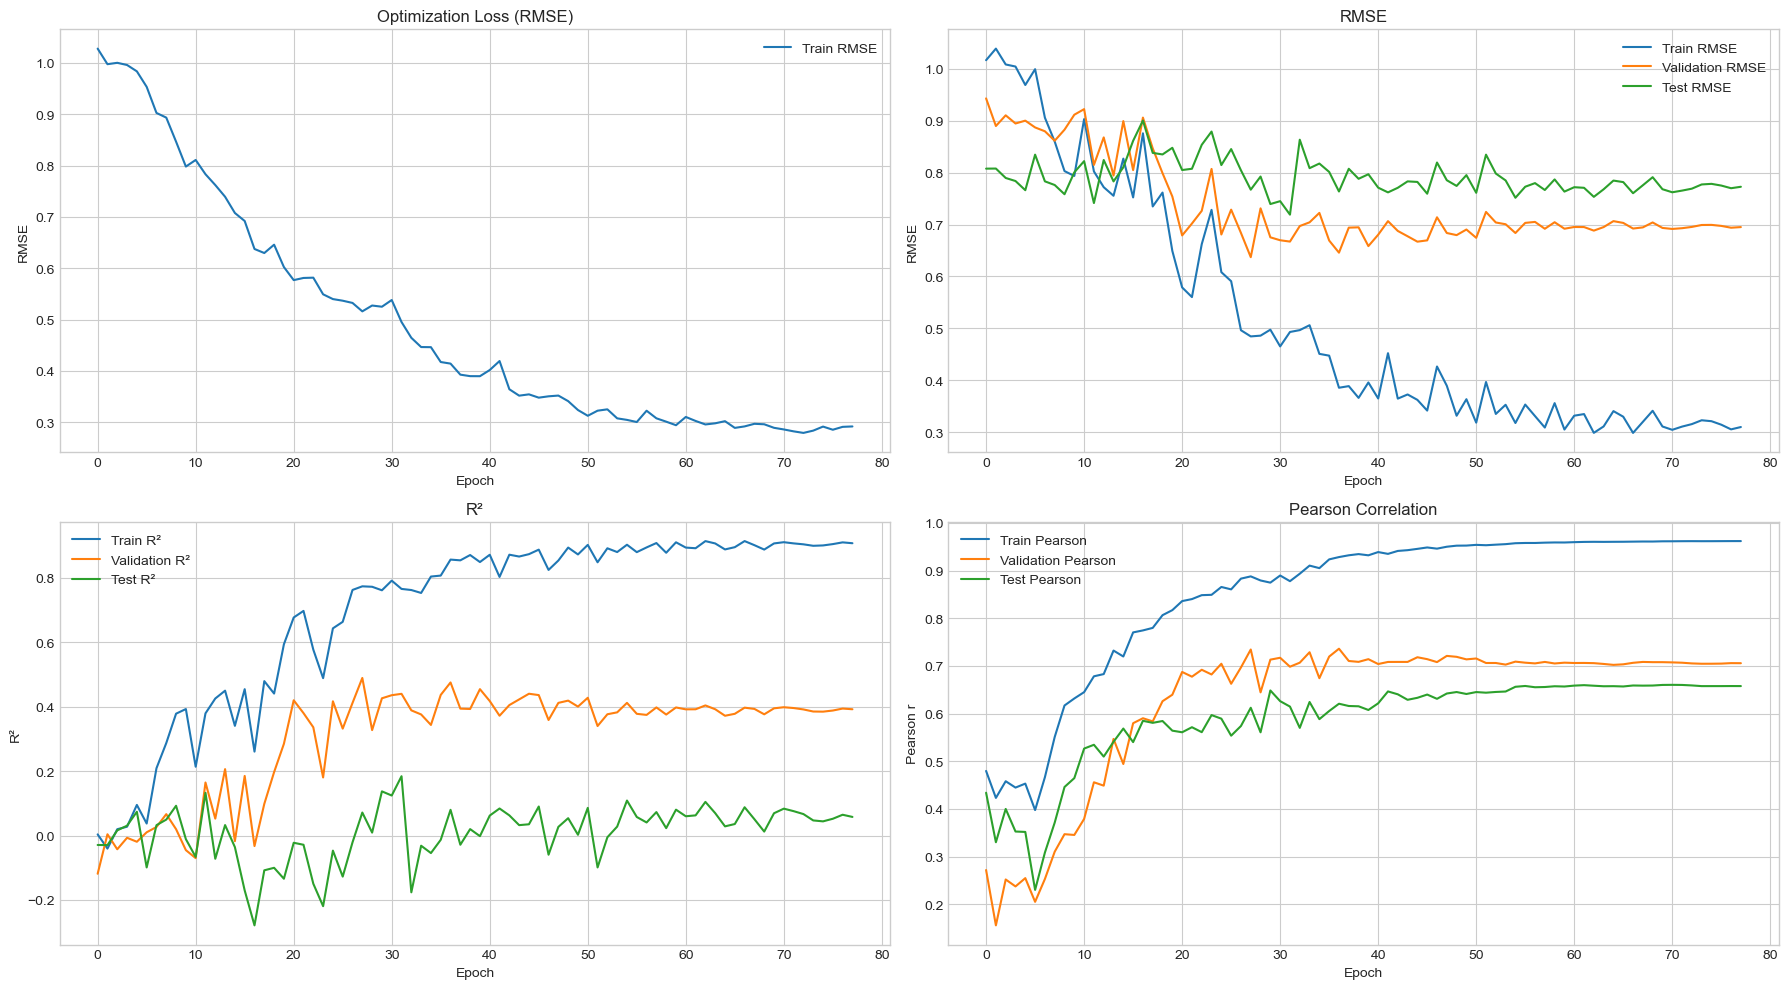

,train_loss,train_rmse,train_r2,train_pearson,val_rmse,val_r2,val_pearson,test_rmse,test_r2,test_pearson
73,0.2837,0.3232,0.8992,0.9617,0.6991,0.3849,0.7046,0.7771,0.0469,0.6577
74,0.2916,0.3214,0.9003,0.9617,0.6993,0.3845,0.7047,0.7783,0.0440,0.6577
75,0.2854,0.3147,0.9045,0.9618,0.6973,0.3879,0.7049,0.7750,0.0521,0.6577
76,0.2911,0.3057,0.9098,0.9619,0.6938,0.3941,0.7059,0.7699,0.0645,0.6578
77,0.2919,0.3102,0.9072,0.9619,0.6951,0.3919,0.7058,0.7727,0.0578,0.6578


In [29]:
# Start from the notebook defaults and optionally replace them with tuned values.
selected_model_config = normalize_model_config()
selected_training_config = normalize_training_config()
config_source = 'base configuration'

if 'best_hparams' in globals():
    tuned_model_overrides = {
        key: best_hparams[key]
        for key in ['hidden_dim', 'num_layers', 'dropout']
        if key in best_hparams
    }
    tuned_training_overrides = {
        key: best_hparams[key]
        for key in ['batch_size', 'learning_rate', 'weight_decay', 'max_epochs', 'patience']
        if key in best_hparams
    }

    if tuned_model_overrides or tuned_training_overrides:
        selected_model_config = normalize_model_config(tuned_model_overrides)
        selected_training_config = normalize_training_config(tuned_training_overrides)
        config_source = 'best hyperparameters from the tuning cell'

print_banner('Final training run')
print(f'Training with {config_source}.')
display(
    pd.DataFrame(
        [
            {'group': 'model', 'name': key, 'value': value}
            for key, value in selected_model_config.items()
        ]
        + [
            {'group': 'training', 'name': key, 'value': value}
            for key, value in selected_training_config.items()
        ]
    )
)

# Rebuild loaders in case the selected batch size changed after tuning.
train_loader, val_loader, test_loader = build_data_loaders(selected_training_config['batch_size'])
model = instantiate_model(selected_model_config)
training_result = fit_regressor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_config=selected_model_config,
    training_config=selected_training_config,
    checkpoint_path=CHECKPOINT_PATH,
    history_path=HISTORY_PATH,
    verbose=True,
)

history = training_result['history']
history_frame = history_to_frame(history)
loss_name = training_result['loss_name']

display_key_values(
    'Best validation checkpoint',
    {
        'Optimization loss': loss_name.upper(),
        'Best epoch': training_result['best_epoch'],
        'Validation RMSE': round(training_result['best_val_rmse'], 4),
        'Validation R²': round(training_result['best_val_r2'], 4),
        'Validation Pearson': round(training_result['best_val_pearson'], 4),
        'Checkpoint path': CHECKPOINT_PATH,
        'History path': HISTORY_PATH,
    },
)

plot_training_history(history_frame, loss_name=loss_name)
display(history_frame.tail().round(4))

## Prediction Cell

Run the next cell after training to reload the saved checkpoint and generate predictions on the test set.

The checkpoint stores the model architecture and normalization settings needed to rebuild the trained regressor. The resulting table contains the PDB identifier, SMILES string, experimental $pIC50$, predicted $pIC50$, and absolute error for each test molecule.

In [17]:
# Reload the best saved model and recover the batch size used for inference.
checkpoint, prediction_model = load_trained_model(CHECKPOINT_PATH)
checkpoint_config = checkpoint['config']
prediction_training_config = normalize_training_config(
    {
        'batch_size': checkpoint_config.get('batch_size', BASE_TRAINING_CONFIG['batch_size']),
    }
)

_, _, prediction_test_loader = build_data_loaders(prediction_training_config['batch_size'])
test_results = evaluate_regression(prediction_model, prediction_test_loader)

predictions_frame = pd.DataFrame(
    {
        'PDB_ID': test_results['pdb_id'],
        'SMILES': test_results['smiles'],
        'pIC50_real': test_results['targets'],
        'pIC50_predicted': test_results['predictions'],
    }
)
predictions_frame['absolute_error'] = (predictions_frame['pIC50_real'] - predictions_frame['pIC50_predicted']).abs()
predictions_frame.to_csv(PREDICTIONS_PATH, index=False)

display_key_values(
    'Prediction summary',
    {
        'Checkpoint path': CHECKPOINT_PATH,
        'Prediction batch size': prediction_training_config['batch_size'],
        'Test RMSE': round(test_results['rmse'], 4),
        'Test R²': round(test_results['r2'], 4),
        'Test Pearson': round(test_results['pearson'], 4),
        'Predictions CSV': PREDICTIONS_PATH,
    },
)

display(predictions_frame.head().round(4))


Prediction summary


,value
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Prediction batch size,32
Test RMSE,0.7671
Test R²,0.0714
Test Pearson,0.6123
Predictions CSV,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


,PDB_ID,SMILES,pIC50_real,pIC50_predicted,absolute_error
0,5RH3,Cc1ccncc1NC(=O)[C@H](C)c2cccc(c2)Cl,4.5817,4.3981,0.1836
1,7GBV,Cc1ccncc1NC(=O)C(C)(C)c2cccc(c2)Cl,4.0135,4.3300,0.3165
2,7GBX,c1ccc2c(c1)ncn2NC(=O)Cc3cccc(c3)Cl,5.0807,4.8838,0.1970
3,7GCV,Cc1ccncc1NC(=O)Cc2cc(cc(c2)Cl)O[C@@H]3CC(=O)N3,5.4402,4.5638,0.8764
4,7GD5,CN(C)c1ccc(cc1)N(Cc2ccsc2)C(=O)Cn3c4ccccc4nn3,5.7462,4.8732,0.8731


## Test Metrics and ROC/AUC

This section summarizes the regression quality on the test set and then derives a binary activity task from the continuous predictions.

Reported metrics:

- Pearson correlation coefficient
- RMSE
- $R^2$
- ROC AUC using the activity threshold `pIC50 >= 6.0`

The ROC plot is helpful for checking whether higher predicted $pIC50$ values also rank actives ahead of inactives, even though the model was trained as a regressor.


Test-set metrics


,metric,value
0,Pearson,0.6123
1,RMSE,0.7671
2,R2,0.0714
3,ROC_AUC,0.7330



Activity class balance used for ROC/AUC


,class_label,count
0,inactive,35
1,active,29


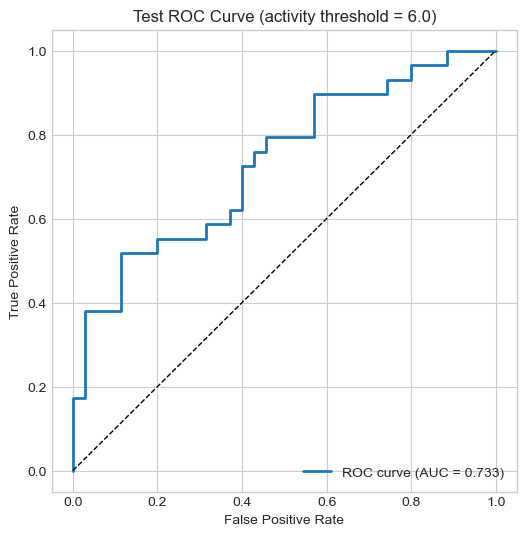

In [18]:
# Reuse the predictions generated in the previous cell.
y_true = test_results['targets']
y_pred = test_results['predictions']

pearson_value = test_results['pearson']
rmse_value = test_results['rmse']
r2_value = test_results['r2']

# Convert the continuous target into a binary activity label for ROC/AUC.
binary_true = (y_true >= ACTIVE_THRESHOLD).astype(int)
if np.unique(binary_true).size < 2:
    raise ValueError('ROC/AUC requires both classes to be present in the test set for the chosen threshold.')

fpr, tpr, _ = roc_curve(binary_true, y_pred)
auc_value = roc_auc_score(binary_true, y_pred)

metrics_frame = pd.DataFrame(
    {
        'metric': ['Pearson', 'RMSE', 'R2', 'ROC_AUC'],
        'value': [pearson_value, rmse_value, r2_value, auc_value],
    }
)
class_balance_frame = pd.DataFrame(
    {
        'class_label': ['inactive', 'active'],
        'count': [(binary_true == 0).sum(), (binary_true == 1).sum()],
    }
)

print_banner('Test-set metrics')
display(metrics_frame.round(4))
print_banner('Activity class balance used for ROC/AUC')
display(class_balance_frame)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_value:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Test ROC Curve (activity threshold = {ACTIVE_THRESHOLD:.1f})')
plt.legend(loc='lower right')
plt.show()

## Predicted vs Real pIC50

The final view compares predicted and experimental values directly. Points close to the diagonal indicate good agreement, while large deviations highlight molecules the model struggles with.

Alongside the scatter plot, the code also lists the worst absolute errors so the hardest test examples can be inspected first.

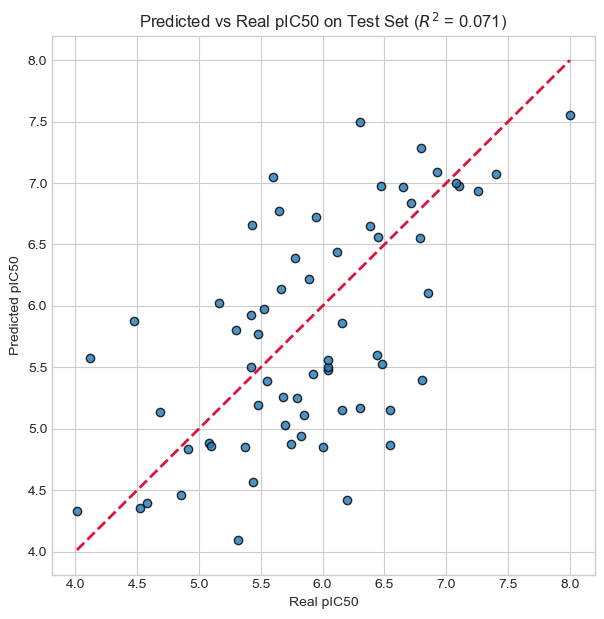


Largest test-set errors


,PDB_ID,SMILES,pIC50_real,pIC50_predicted,absolute_error,residual
7,7GEB,Cc1ccncc1NC(=O)CN2CCN(CC2)C(=O)C,6.1952,4.4199,1.7753,-1.7753
13,7GFM,CN(C)c1ccc(cc1)N(Cc2ccsc2)C(=O)Cc3cncc4c3cccc4,6.5457,4.8644,1.6813,-1.6813
9,7GEZ,CC(=O)N1CCN(CC1)CC(=O)Nc2cncc3c2cccc3,4.1216,5.5756,1.4540,1.4540
41,7GM0,Cn1c2c(cncc2NC(=O)[C@@H]3CN(Cc4c3cc(cc4)Cl)S(=...,5.5968,7.0468,1.4500,1.4500
30,7GJM,C[C@H]1COc2ccc(cc2[C@@H]1C(=O)Nc3cncc4c3cccc4)Cl,6.8048,5.3989,1.4060,-1.4060
16,7GG8,c1cc(cc(c1)Cl)CC(=O)N2CCCc3c2cncc3N,4.4754,5.8806,1.4053,1.4053
19,7GI7,CN(C)c1ccc(nc1)N(Cc2cccc(c2)Cl)C(=O)Cc3cncc4c3...,6.5424,5.1562,1.3862,-1.3862
53,7GNE,C[C@@]1(CNS(=O)(=O)c2c1cc(cc2)Cl)C(=O)Nc3cncc4...,5.4291,6.6546,1.2255,1.2255
21,7GIC,Cc1cccc(c1)CC(=O)Nc2cncc3c2cccc3,5.3183,4.0960,1.2223,-1.2223
62,8UEH,c1ccc(cc1)CCNC(=O)C[C@H](Cc2ccc(cc2)F)NC(=O)[C...,6.3010,7.4933,1.1923,1.1923


In [20]:
# Plot predicted versus experimental pIC50 values.
comparison_frame = predictions_frame.copy()
comparison_frame['residual'] = comparison_frame['pIC50_predicted'] - comparison_frame['pIC50_real']
comparison_frame['absolute_error'] = comparison_frame['residual'].abs()

plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.8, edgecolor='black')

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--', color='crimson', linewidth=2)

plt.xlabel('Real pIC50')
plt.ylabel('Predicted pIC50')
plt.title(f'Predicted vs Real pIC50 on Test Set ($R^2$ = {r2_value:.3f})')
plt.xlim(min_value - 0.2, max_value + 0.2)
plt.ylim(min_value - 0.2, max_value + 0.2)
plt.show()

print_banner('Largest test-set errors')
display(
    comparison_frame.sort_values('absolute_error', ascending=False).head(10).round(4)
)

### External SMILES Inference

This cell scores three DiGress-generated SMILES files from the MPro fine-tune runs performed after PDBbind pretraining.

The process has four parts:

1. Load all non-empty SMILES lines from the three curated `valid_unique_molecules_*.txt` files.
2. Convert each valid SMILES into the same molecular graph representation used during training. Invalid or non-parseable SMILES are skipped per source file.
3. Run the trained regression model on each source file separately and transform the outputs back from the normalized scale into the original pIC50 scale.
4. Save one CSV per source file inside `ARTIFACT_DIR`, keeping the Apr 14, Apr 21, and Apr 28 outputs separate for easier comparison and provenance tracking.

This makes it possible to score all three generated sets without retraining the regressor.

In [24]:
EXTERNAL_OUTPUTS_ROOT = REPO_ROOT.parent / 'outputsDEF'
EXTERNAL_SMILES_SOURCES = {
    '14Apr2026': EXTERNAL_OUTPUTS_ROOT / '14Apr2026' / 'mpro_finetune_20260414_163410_resume' / 'valid_unique_molecules_e75_b1.txt',
    '21Apr2026': EXTERNAL_OUTPUTS_ROOT / '21Apr2026' / 'mpro_finetune_smallbs_resume' / 'valid_unique_molecules_e80_b1.txt',
    '28Apr2026_mpro_upgraded': EXTERNAL_OUTPUTS_ROOT / '28Apr2026' / '17-56-48-mpro_upgraded' / 'graphs' / 'mpro_upgraded' / 'valid_unique_molecules_e320_b65.txt',
}
EXTERNAL_PREDICTION_OUTPUTS = {
    source_label: ARTIFACT_DIR / f'external_predictions_{source_label}.csv'
    for source_label in EXTERNAL_SMILES_SOURCES
}


def load_external_smiles_file(smiles_path: Path) -> List[str]:
    """Load one newline-separated SMILES file and return non-empty entries."""
    if not smiles_path.exists():
        raise FileNotFoundError(f'External SMILES file not found: {smiles_path}')

    smiles_list = []
    for raw_line in smiles_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if line:
            smiles_list.append(line.split()[0])
    return smiles_list


checkpoint, external_model = load_trained_model(CHECKPOINT_PATH)
external_model.eval()
external_inference_batch_size = normalize_training_config(
    {'batch_size': checkpoint['config'].get('batch_size', BASE_TRAINING_CONFIG['batch_size'])}
 )['batch_size']

external_prediction_frames = {}
summary_rows = []

with torch.no_grad():
    for source_label, smiles_path in EXTERNAL_SMILES_SOURCES.items():
        external_smiles_list = load_external_smiles_file(smiles_path)

        external_graphs = []
        failed_smiles = []
        for row_idx, smi in enumerate(external_smiles_list):
            try:
                graph = molecule_to_graph(smi, target=0.0, pdb_id=f'{source_label}_{row_idx:05d}')
                external_graphs.append(graph)
            except ValueError:
                failed_smiles.append(smi)

        if external_graphs:
            external_dataset = MoleculeGraphDataset(external_graphs, y_mean=TARGET_MEAN, y_std=TARGET_STD)
            external_loader = DataLoader(
                external_dataset,
                batch_size=external_inference_batch_size,
                shuffle=False,
                collate_fn=collate_graphs,
            )

            source_predictions = []
            source_smiles = []
            for batch in external_loader:
                batch = move_batch_to_device(batch, DEVICE)
                pred_norm = external_model(batch)
                pred_original = pred_norm.cpu().numpy() * TARGET_STD + TARGET_MEAN
                source_predictions.append(pred_original)
                source_smiles.extend(batch['smiles'])

            predicted_pic50 = np.concatenate(source_predictions)
        else:
            source_smiles = []
            predicted_pic50 = np.array([], dtype=np.float32)

        output_path = EXTERNAL_PREDICTION_OUTPUTS[source_label]
        external_predictions_frame = pd.DataFrame({
            'SMILES': source_smiles,
            'pIC50': predicted_pic50,
        })
        external_predictions_frame.to_csv(output_path, index=False)

        external_prediction_frames[source_label] = external_predictions_frame
        summary_rows.append({
            'source': source_label,
            'smiles_file': str(smiles_path),
            'output_csv': str(output_path),
            'input_smiles': len(external_smiles_list),
            'predicted_smiles': len(external_predictions_frame),
            'failed_smiles': len(failed_smiles),
        })

        print(f'Saved {len(external_predictions_frame)} predictions for {source_label} to: {output_path}')
        if failed_smiles:
            print(f'Warning: {len(failed_smiles)} SMILES from {source_label} could not be parsed and were skipped.')

external_summary_frame = pd.DataFrame(summary_rows)
print_banner('External inference summary')
display(external_summary_frame)

for source_label, external_predictions_frame in external_prediction_frames.items():
    print_banner(f'Top predictions: {source_label}')
    display(external_predictions_frame.head(10).round(4))

Saved 1802 predictions for 14Apr2026 to: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\external_predictions_14Apr2026.csv
Saved 1780 predictions for 21Apr2026 to: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\external_predictions_21Apr2026.csv
Saved 446 predictions for 28Apr2026_mpro_upgraded to: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\external_predictions_28Apr2026_mpro_upgraded.csv

External inference summary


,source,smiles_file,output_csv,input_smiles,predicted_smiles,failed_smiles
0,14Apr2026,C:\Users\xaviv\URV\.MESIIA\TFM\repo\outputsDEF...,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...,1802,1802,0
1,21Apr2026,C:\Users\xaviv\URV\.MESIIA\TFM\repo\outputsDEF...,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...,1780,1780,0
2,28Apr2026_mpro_upgraded,C:\Users\xaviv\URV\.MESIIA\TFM\repo\outputsDEF...,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...,446,446,0



Top predictions: 14Apr2026


,SMILES,pIC50
0,N#CC1NC(CO)C1O,4.6044
1,N#CC1COCC1O,4.5048
2,N#S(=O)CC1=CC=C1NCC1C#CC1=O,6.5009
3,CC1(O)CC1Br,4.7395
4,O=C1CC(O)CCC(O)CC1O,4.8505
5,NC(O)C1NC#CCCO1,5.0314
6,CC(O)(Br)C1=C(Br)C(COC=[O+]O)=C1,6.1042
7,C#CC(NC(=O)C(C)C)C(O)C(=O)O,5.6178
8,N#CC(S)CS(=O)NC(=O)C(=O)S(N)(=O)=O,5.5713
9,O=C1C=CNC2CCC(O1)C2O,4.9605



Top predictions: 21Apr2026


,SMILES,pIC50
0,CC1=CC(O)(CCC(N)=O)C=C1,5.4751
1,O=CCC1NC(=O)CC1C#CCF,5.4085
2,C#CC(NS(N)(=O)=O)C(O)C(O)C=O,5.9804
3,NC(=O)C1=CC(C(=O)N2CCC2)=C1O,5.6429
4,CC(O)CC1NC1CC(CO)C(=O)O,4.8794
5,OC1CC(O)C(O)C1,4.4416
6,O=C(O)C12C#CC(C3CO3)CC1OCC1(O)C(=O)C1C#C2,6.3929
7,O=C1[N+]#CN1,4.4207
8,CCC1(O)NC(C)=NC1=O,5.3989
9,CC(=O)C1NC1=O,4.9429



Top predictions: 28Apr2026_mpro_upgraded


,SMILES,pIC50
0,OC12C=C3C4=C1C2=c1cccc3c1=C4,5.2155
1,CC1=CC=C2C=C2C=CC2(CN2)C(N)=C1Cl,6.0248
2,Clc1cc2ccc-2cccccccn1,4.7564
3,CC1=CC=CC=C2C=C3C2=C3C1(O)CO,5.1706
4,C1=Cc2cc1ccc1ccn2-1,4.3783
5,Clc1c2cncc3cccc3ccnc12,5.5655
6,CN1C=C1C1=CC=C2C=C3C1=CC23Cl,6.1521
7,Clc1cccccc2cc-2c1,4.8246
8,C1=CC2=C3C(=C3N=C1)C=Cc1cc2co1,4.4861
9,C1=NC(C2=Cc3ncccc32)=C1,4.4181
